Features used for training: ['release_year', 'rating', 'country', 'listed_in', 'duration_num']


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.99780429 0.99796115 0.99749056 0.99749056 0.99701998 0.99701998
 0.99686299 0.99686299 0.99686299 0.99686299 0.99654939 0.99686299
        nan 0.99796115        nan 0.99796103        nan 0.99717684
        nan 0.9973337         nan 0.99717696        nan 0.99733358]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


------------------------------
Best Parameters: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 3, 'classifier__weights': 'distance'}
Final Test Accuracy: 99.56%
------------------------------

Classification Report:
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1117
     TV Show       1.00      0.99      0.99       477

    accuracy                           1.00      1594
   macro avg       1.00      0.99      0.99      1594
weighted avg       1.00      1.00      1.00      1594

Confusion Matrix:
[[1115    2]
 [   5  472]]


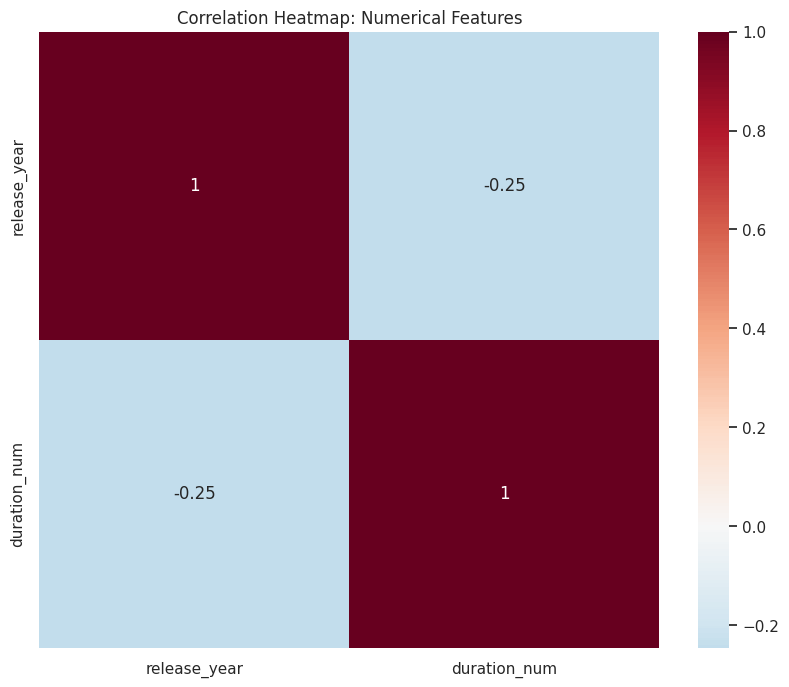

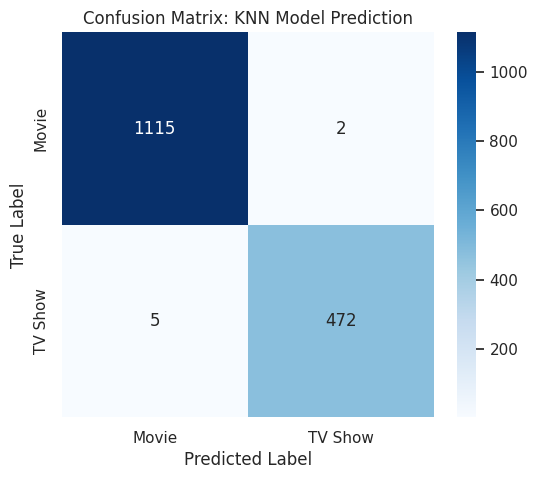

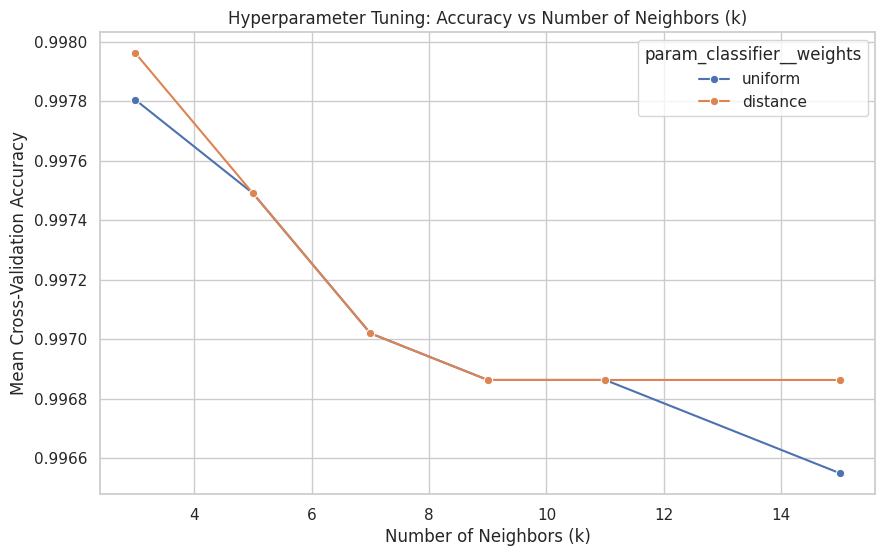

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found u

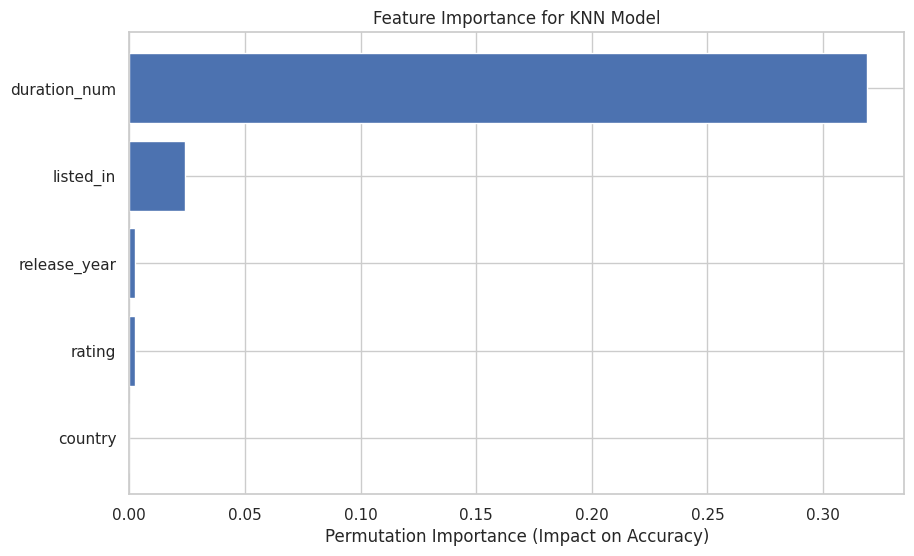

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# =============================
# LOAD NETFLIX DATASET
# =============================
df = pd.read_csv("netflix_titles.csv")
df.columns = df.columns.str.strip()

# =============================
# DATA CLEANING (NETFLIX VERSION)
# =============================
df = df[['type','release_year','rating','country','listed_in','duration']].copy()

# Convert duration text → numeric
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
df.drop('duration', axis=1, inplace=True)

df.dropna(inplace=True)

# Target column
target_col = 'type'

X = df.drop(target_col, axis=1)
y = df[target_col]

print(f"Features used for training: {X.columns.tolist()}")

# =============================
# PREPROCESSOR (SAME PIPELINE STYLE)
# =============================
categorical_features = X.select_dtypes(include=['object','category']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64','float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)

knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

# =============================
# TRAIN / TEST SPLIT
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =============================
# GRID SEARCH (HYPERPARAMETERS)
# =============================
param_grid = {
    'classifier__n_neighbors': [3,5,7,9,11,15],
    'classifier__weights': ['uniform','distance'],
    'classifier__metric': ['euclidean','manhattan']
}

grid_search = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("-"*30)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("-"*30)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# =============================
# CORRELATION HEATMAP (NUMERICAL)
# =============================
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,8))
corr_matrix = df[numerical_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)

plt.title("Correlation Heatmap: Numerical Features")
plt.show()

# =============================
# CONFUSION MATRIX HEATMAP
# =============================
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Movie','TV Show'],
    yticklabels=['Movie','TV Show']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: KNN Model Prediction')
plt.show()

# =============================
# HYPERPARAMETER CURVE GRAPH
# =============================
results_df = pd.DataFrame(grid_search.cv_results_)
subset = results_df[results_df['param_classifier__metric']=='euclidean']

plt.figure(figsize=(10,6))
sns.lineplot(
    data=subset,
    x='param_classifier__n_neighbors',
    y='mean_test_score',
    hue='param_classifier__weights',
    marker='o'
)

plt.title('Hyperparameter Tuning: Accuracy vs Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.show()

# =============================
# PERMUTATION IMPORTANCE
# =============================
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(10,6))
plt.barh(X.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])

plt.xlabel("Permutation Importance (Impact on Accuracy)")
plt.title("Feature Importance for KNN Model")
plt.show()
